# Regression
using california housing dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras import datasets, layers, Sequential, metrics

## 1- Data Preparation

### Load and Inspect the Dataset

In [3]:
(train_data, train_targets), (test_data, test_targets) = datasets.california_housing.load_data(
    version='small')

In [4]:
print(train_data.shape)
print(train_targets.shape)
print(test_data.shape)
print(test_targets.shape)

(480, 8)
(480,)
(120, 8)
(120,)


In [5]:
train_data[0]

array([-1.2224e+02,  3.7730e+01,  2.1000e+01,  7.0310e+03,  1.2490e+03,
        2.9300e+03,  1.2350e+03,  4.5213e+00], dtype=float32)

In [6]:
train_targets[0]

np.float32(228400.0)

### Pre-processing

In [7]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

x_train = (train_data - mean)/std
x_test = (test_data - mean)/std

In [8]:
y_train = train_targets / 10_000
y_test = test_targets / 10_000

## 2- Model Design

In [9]:
def get_model():
    model = Sequential([
        layers.Input(shape=(x_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model

model = get_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3- Training

In [10]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


## 4- Evaluation

In [13]:
(sum(all_scores) / len(all_scores)) * 10_000

35270.60568332672

In [14]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [15]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

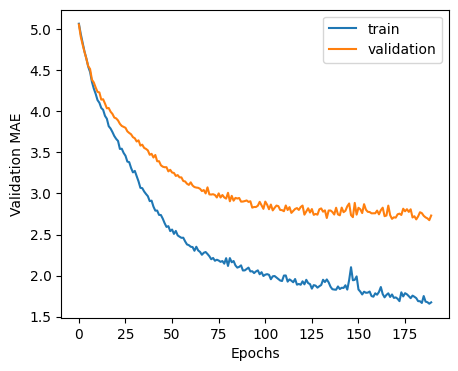

In [25]:
plt.figure(figsize=(5,4))
plt.plot(history.history['mean_absolute_error'][10:], label="train")
plt.plot(average_mae_history[10:], label="validation")
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.legend()
plt.show()

## 5- Deploy

In [26]:
y_preds_normalized = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [28]:
y_preds = y_preds_normalized * 10_000

In [29]:
y_preds[0:3]

array([[201604.98 ],
       [173207.22 ],
       [122524.664]], dtype=float32)

In [31]:
test_targets[0:3]

array([218800., 218400.,  93800.], dtype=float32)